# 03 · Filing signal vs reported KPIs

Do FAA tower filings lead what the tower REITs and carriers report? Signals are **point-in-time** quarterly
counts from `data/parquet/features_quarterly.parquet` (`py -m faa_oe features`): sponsor-attributed filings,
split into `modification` (an existing structure was on record before the filing) and `new_or_unknown`.
KPIs come from `ground_truth/tower_kpis.csv` (hand-collected, awaiting spot-check) and SEC XBRL carrier capex
(`py -m faa_oe truth`). Leads were fixed before looking at out-of-sample results (see `backtest.py`): 4 quarters
for towers built / sites constructed, 3 for capex, 1 for modification filings vs organic growth or leasing revenue.

In [1]:
import logging
from datetime import date, timedelta

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import polars as pl

from faa_oe import backtest, features, report, truth
from faa_oe import viz
from faa_oe.paths import DataPaths

viz.apply_style()
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(60)

# None = first quarter of the last unbroken covered run of the FAA pull; or e.g. truth.quarter_start("2016Q1").
START = date(2017, 1, 1)

panel = features.load_panel("Q")
tdf = truth.load_truth()
start = START or features.default_start(panel)
res = backtest.run(panel, tdf, start=start)
pairs = {p.key: p for p in backtest.PAIRINGS}
print(f"signal from {truth.quarter_label(start)}; {res.oos.height} pairings run; skipped: {res.skipped or 'none'}")
truth.coverage_table(tdf)

signal from 2017Q1; 14 pairings run; skipped: none


entity,metric,unit,source,n,first,last
str,str,str,str,u32,str,str
"""AMT""","""sites_constructed_total""","""sites""","""kpi_csv""",28,"""2015Q1""","""2024Q2"""
"""AMT""","""sites_constructed_total_ex_india""","""sites""","""kpi_csv""",8,"""2024Q3""","""2026Q2"""
"""AMT""","""sites_constructed_usc""","""sites""","""kpi_csv""",36,"""2015Q1""","""2026Q2"""
"""AMT""","""total_organic_tenant_billings_growth_pct""","""pct""","""kpi_csv""",44,"""2015Q3""","""2026Q2"""
"""AMT""","""usc_organic_tenant_billings_growth_pct""","""pct""","""kpi_csv""",44,"""2015Q3""","""2026Q2"""
"""CCI""","""organic_site_rental_billings_growth_pct""","""pct""","""kpi_csv""",18,"""2022Q1""","""2026Q2"""
"""CCI""","""organic_site_rental_billings_growth_unadj_pct""","""pct""","""kpi_csv""",14,"""2023Q1""","""2026Q2"""
"""CCI""","""organic_site_rental_revenue_growth_pct""","""pct""","""kpi_csv""",28,"""2015Q1""","""2021Q4"""
"""CCI""","""towers_organic_billings_growth_pct""","""pct""","""kpi_csv""",15,"""2022Q4""","""2026Q2"""


## Signal and KPI, aligned at the pre-specified lead
Top: the filing signal's year-on-year log change, plotted *lead* quarters later so it sits over the KPI quarter
it is meant to predict. Bottom: the KPI's YoY change (log for counts and dollars, percentage points for growth
rates). Two panels, not two axes: each has its own scale.

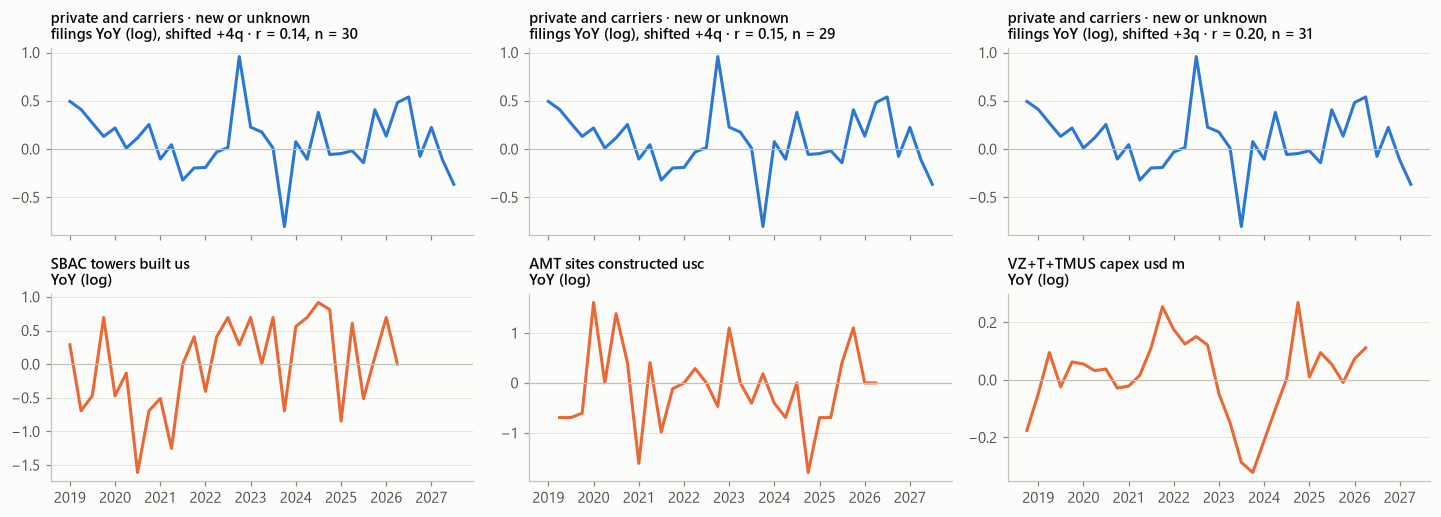

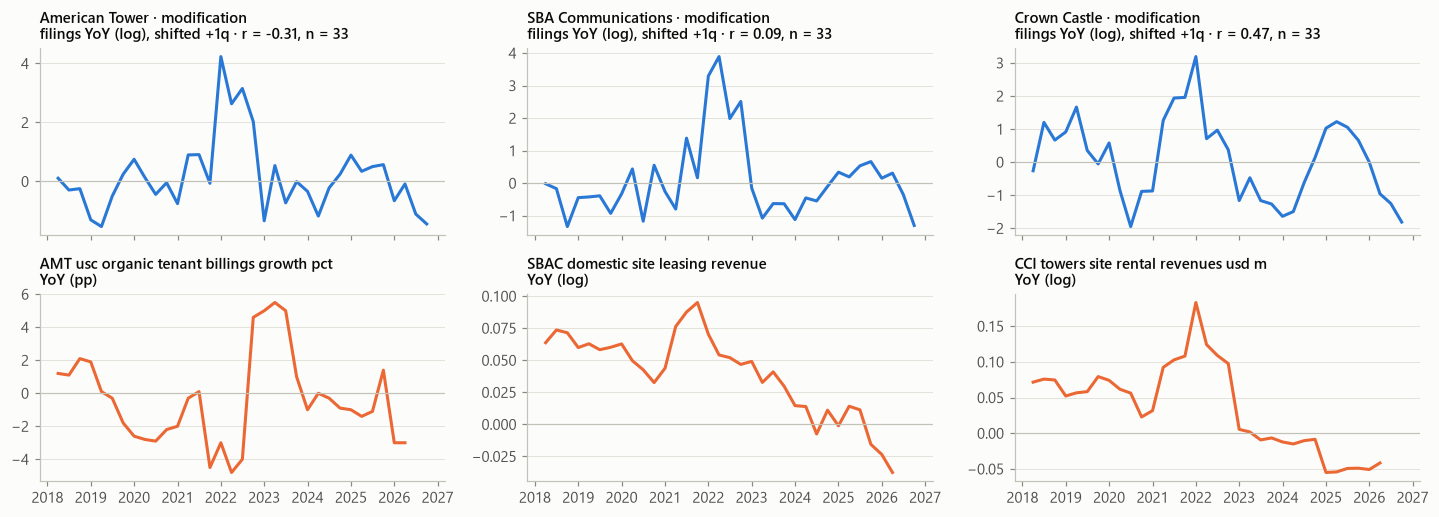

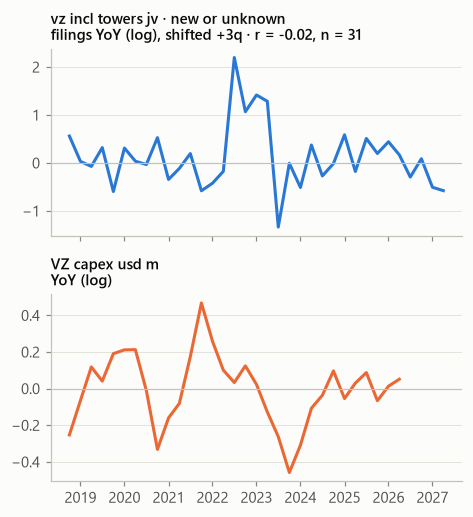

In [2]:
OVERLAY = [k for k in ("a1", "a3", "a5", "b1", "b2", "b6", "c1") if k in set(res.oos["key"].to_list())]


def overlay(keys):
    fig, axes = plt.subplots(2, len(keys), figsize=(4.4 * len(keys), 4.8), sharex="col", squeeze=False)
    for j, key in enumerate(keys):
        p = pairs[key]
        d = res.data.filter(pl.col("key") == key).sort("period")
        shifted = d.select(period=pl.col("period").dt.offset_by(f"{3 * p.lead}mo"), x="x").drop_nulls()
        kpi = d.select("period", "y").drop_nulls().filter(pl.col("period") >= shifted["period"].min())
        top, bot = axes[0][j], axes[1][j]
        top.plot(shifted["period"], shifted["x"], color=viz.SERIES[0], linewidth=2)
        bot.plot(kpi["period"], kpi["y"], color=viz.SERIES[1], linewidth=2)
        for ax in (top, bot):
            ax.axhline(0, color=viz.AXIS, linewidth=0.8)
        unit = backtest.kpi_unit(tdf, p.kpi_entity, p.kpi_metric)
        r = res.oos.filter(pl.col("key") == key)["corr_at_lead"][0]
        n = res.leadlag.filter((pl.col("key") == key) & (pl.col("transform") == "yoy") & (pl.col("lead") == p.lead))["n"][0]
        stat = f"r = {r:.2f}, n = {n}" if r is not None else f"n = {n}"
        top.set_title(f"{p.signal.replace('_', ' ')} · {p.kind.replace('_', ' ')}\n"
                      f"filings YoY (log), shifted +{p.lead}q · {stat}", fontsize=9.5)
        bot.set_title(f"{p.kpi_entity} {p.kpi_metric.replace('_', ' ')}\nYoY " + ("(pp)" if unit == "pct" else "(log)"),
                      fontsize=9.5)
        bot.xaxis.set_major_locator(mdates.YearLocator())
        bot.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    fig.tight_layout()
    return fig


for i in range(0, len(OVERLAY), 3):
    overlay(OVERLAY[i:i + 3])

## Lead-lag correlations
corr(signal at t − k, KPI at t) for k = 0…6 quarters, YoY transforms. Whiskers are 95% intervals: moving-block
bootstrap when n ≥ 12, Fisher-z (too narrow, ignores autocorrelation) below that. The pre-specified lead is the
blue bar. With this many pairings and leads, a few large bars are expected by chance.

no lead with enough overlapping quarters: none


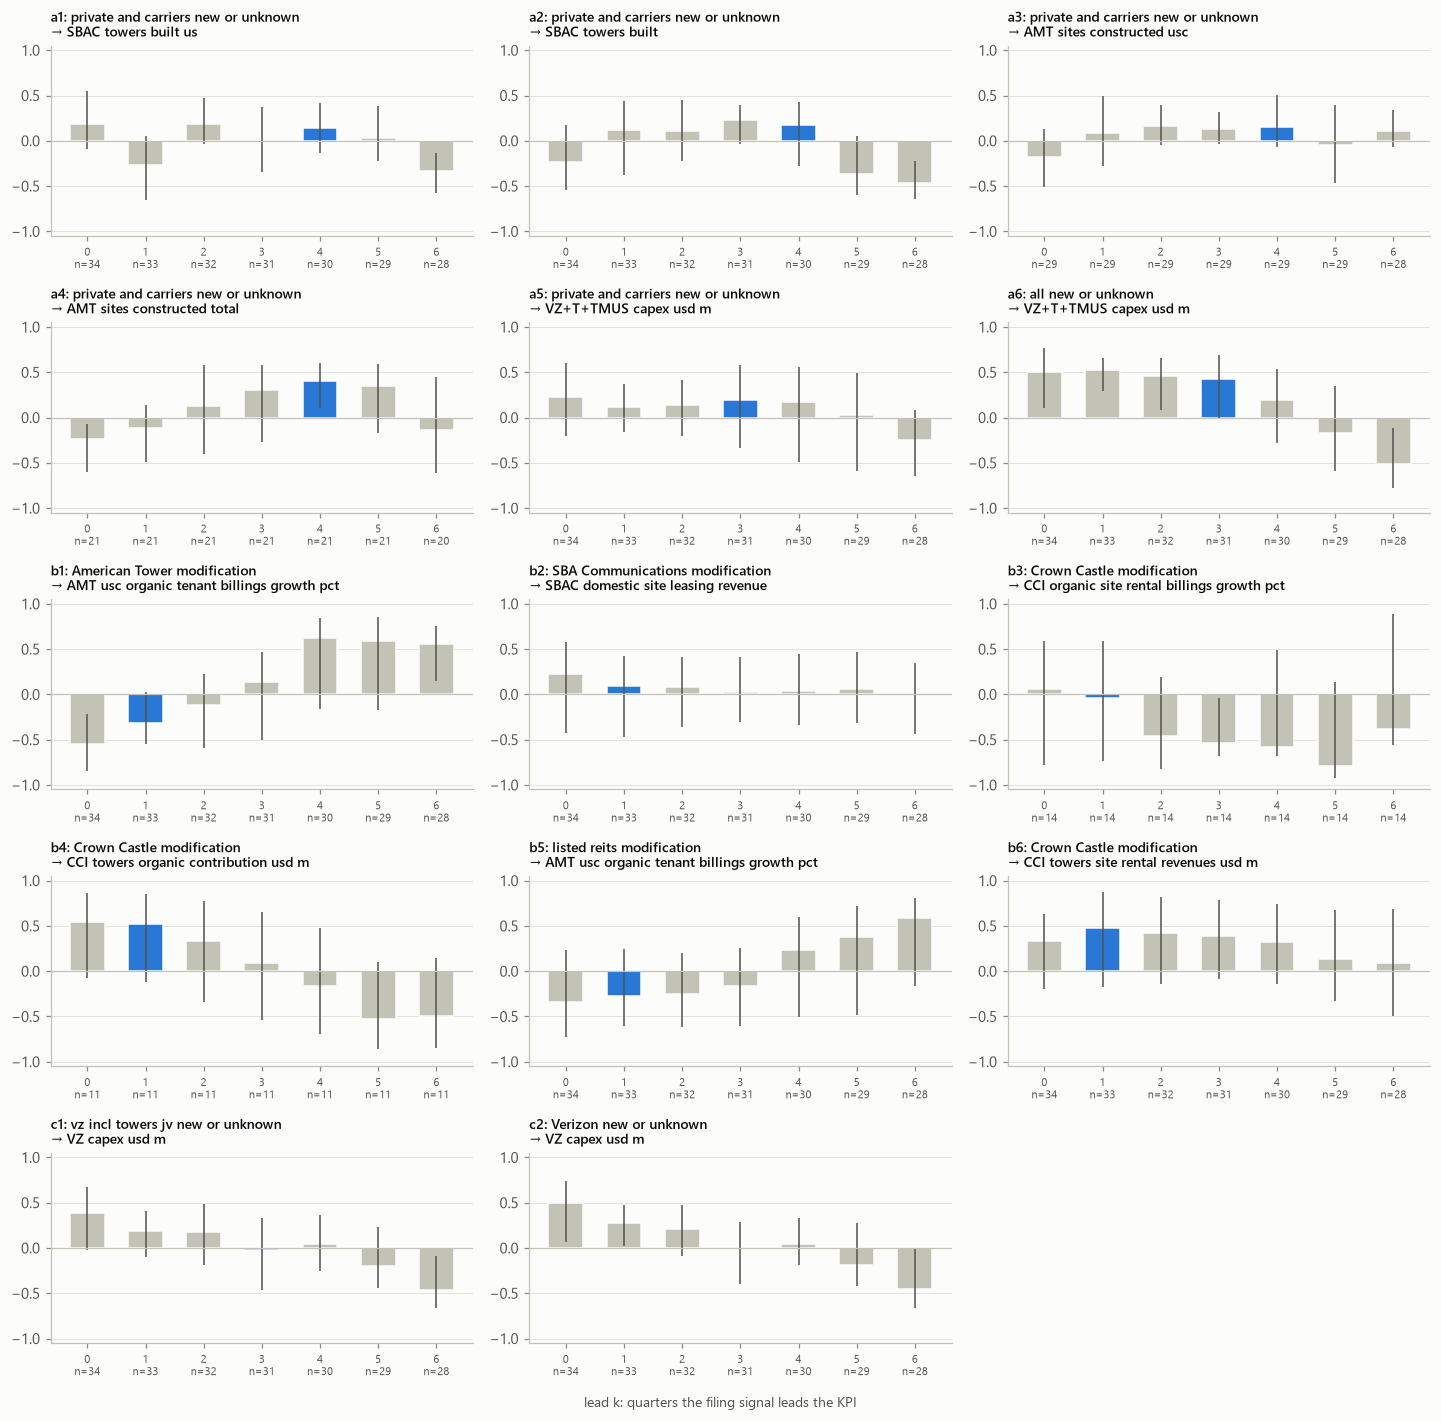

In [3]:
keys = res.oos["key"].to_list()
has_corr = set(res.leadlag.filter((pl.col("transform") == "yoy") & pl.col("corr").is_not_null())["key"].to_list())
print("no lead with enough overlapping quarters:", [k for k in keys if k not in has_corr] or "none")
keys = [k for k in keys if k in has_corr]
fig, axes = viz.small_multiples(len(keys), ncols=3, panel=(4.4, 2.6))
for ax, key in zip(axes, keys):
    p = pairs[key]
    d = res.leadlag.filter((pl.col("key") == key) & (pl.col("transform") == "yoy")).sort("lead")
    ok = d.filter(pl.col("corr").is_not_null())
    colors = [viz.SERIES[0] if k == p.lead else viz.OTHER for k in ok["lead"]]
    ax.bar(ok["lead"], ok["corr"], width=0.6, color=colors, edgecolor=viz.SURFACE, linewidth=1)
    err = [(ok["corr"] - ok["ci_lo"]).to_list(), (ok["ci_hi"] - ok["corr"]).to_list()]
    ax.errorbar(ok["lead"], ok["corr"], yerr=err, fmt="none", ecolor=viz.INK_2, elinewidth=1, capsize=0)
    ax.axhline(0, color=viz.AXIS, linewidth=0.8)
    ax.set_ylim(-1.05, 1.05)
    ax.set_xticks(d["lead"].to_list(), [f"{k}\nn={n}" for k, n in zip(d["lead"], d["n"])], fontsize=7.5)
    ax.set_title(f"{key}: {p.signal.replace('_', ' ')} {p.kind.replace('_', ' ')}\n→ {p.kpi_entity} "
                 f"{p.kpi_metric.replace('_', ' ')}", fontsize=9)
fig.supxlabel("lead k: quarters the filing signal leads the KPI", fontsize=9, color=viz.INK_2)
fig.tight_layout()

In [4]:
backtest.wide_leadlag(res.leadlag, "yoy")

key,signal,kind,kpi,0,1,2,3,4,5,6
str,str,str,str,str,str,str,str,str,str,str
"""a1""","""private_and_carriers""","""new_or_unknown""","""SBAC towers_built_us""","""0.19 [-0.09, 0.55] (34)""","""-0.27 [-0.66, 0.05] (33)""","""0.18 [-0.04, 0.47] (32)""","""-0.01 [-0.34, 0.38] (31)""","""0.14 [-0.13, 0.42] (30)""","""0.04 [-0.22, 0.39] (29)""","""-0.33 [-0.58, -0.13] (28)"""
"""a2""","""private_and_carriers""","""new_or_unknown""","""SBAC towers_built""","""-0.23 [-0.55, 0.18] (34)""","""0.12 [-0.37, 0.43] (33)""","""0.11 [-0.23, 0.45] (32)""","""0.23 [-0.03, 0.4] (31)""","""0.18 [-0.28, 0.43] (30)""","""-0.37 [-0.59, 0.05] (29)""","""-0.47 [-0.65, -0.22] (28)"""
"""a3""","""private_and_carriers""","""new_or_unknown""","""AMT sites_constructed_usc""","""-0.18 [-0.51, 0.13] (29)""","""0.09 [-0.28, 0.5] (29)""","""0.16 [-0.04, 0.39] (29)""","""0.13 [-0.04, 0.32] (29)""","""0.15 [-0.07, 0.5] (29)""","""-0.05 [-0.46, 0.4] (29)""","""0.11 [-0.07, 0.34] (28)"""
"""a4""","""private_and_carriers""","""new_or_unknown""","""AMT sites_constructed_total""","""-0.24 [-0.6, -0.07] (21)""","""-0.11 [-0.49, 0.14] (21)""","""0.12 [-0.4, 0.58] (21)""","""0.3 [-0.27, 0.58] (21)""","""0.4 [0.11, 0.6] (21)""","""0.35 [-0.17, 0.59] (21)""","""-0.14 [-0.61, 0.45] (20)"""
"""a5""","""private_and_carriers""","""new_or_unknown""","""VZ+T+TMUS capex_usd_m""","""0.23 [-0.21, 0.61] (34)""","""0.11 [-0.16, 0.38] (33)""","""0.14 [-0.2, 0.41] (32)""","""0.2 [-0.34, 0.58] (31)""","""0.18 [-0.49, 0.55] (30)""","""0.03 [-0.59, 0.5] (29)""","""-0.25 [-0.64, 0.09] (28)"""
"""a6""","""all""","""new_or_unknown""","""VZ+T+TMUS capex_usd_m""","""0.5 [0.1, 0.77] (34)""","""0.52 [0.29, 0.66] (33)""","""0.46 [0.09, 0.66] (32)""","""0.42 [-0.02, 0.69] (31)""","""0.2 [-0.28, 0.54] (30)""","""-0.17 [-0.59, 0.35] (29)""","""-0.52 [-0.78, -0.11] (28)"""
"""b1""","""American Tower""","""modification""","""AMT usc_organic_tenant_billings_growth_pct""","""-0.55 [-0.84, -0.22] (34)""","""-0.31 [-0.54, 0.03] (33)""","""-0.12 [-0.59, 0.23] (32)""","""0.13 [-0.5, 0.47] (31)""","""0.63 [-0.16, 0.84] (30)""","""0.59 [-0.17, 0.86] (29)""","""0.55 [0.15, 0.76] (28)"""
"""b2""","""SBA Communications""","""modification""","""SBAC domestic_site_leasing_revenue""","""0.23 [-0.42, 0.58] (34)""","""0.09 [-0.47, 0.42] (33)""","""0.08 [-0.36, 0.41] (32)""","""0.03 [-0.31, 0.42] (31)""","""0.04 [-0.34, 0.44] (30)""","""0.06 [-0.32, 0.46] (29)""","""-0.01 [-0.43, 0.35] (28)"""
"""b3""","""Crown Castle""","""modification""","""CCI organic_site_rental_billings_growth_pct""","""0.06 [-0.78, 0.59] (14)""","""-0.03 [-0.73, 0.59] (14)""","""-0.45 [-0.83, 0.19] (14)""","""-0.54 [-0.68, -0.04] (14)""","""-0.58 [-0.68, 0.49] (14)""","""-0.79 [-0.92, 0.14] (14)""","""-0.38 [-0.56, 0.88] (14)"""


## Out-of-sample nowcast
Each quarter, OLS of the KPI (YoY) on the signal at the pre-specified lead, fitted only on earlier quarters
(expanding window, ≥ 8 training pairs), against the last KPI value and against "same quarter last year"
(no YoY change: the zero line). Ratios below 1 favour the signal.

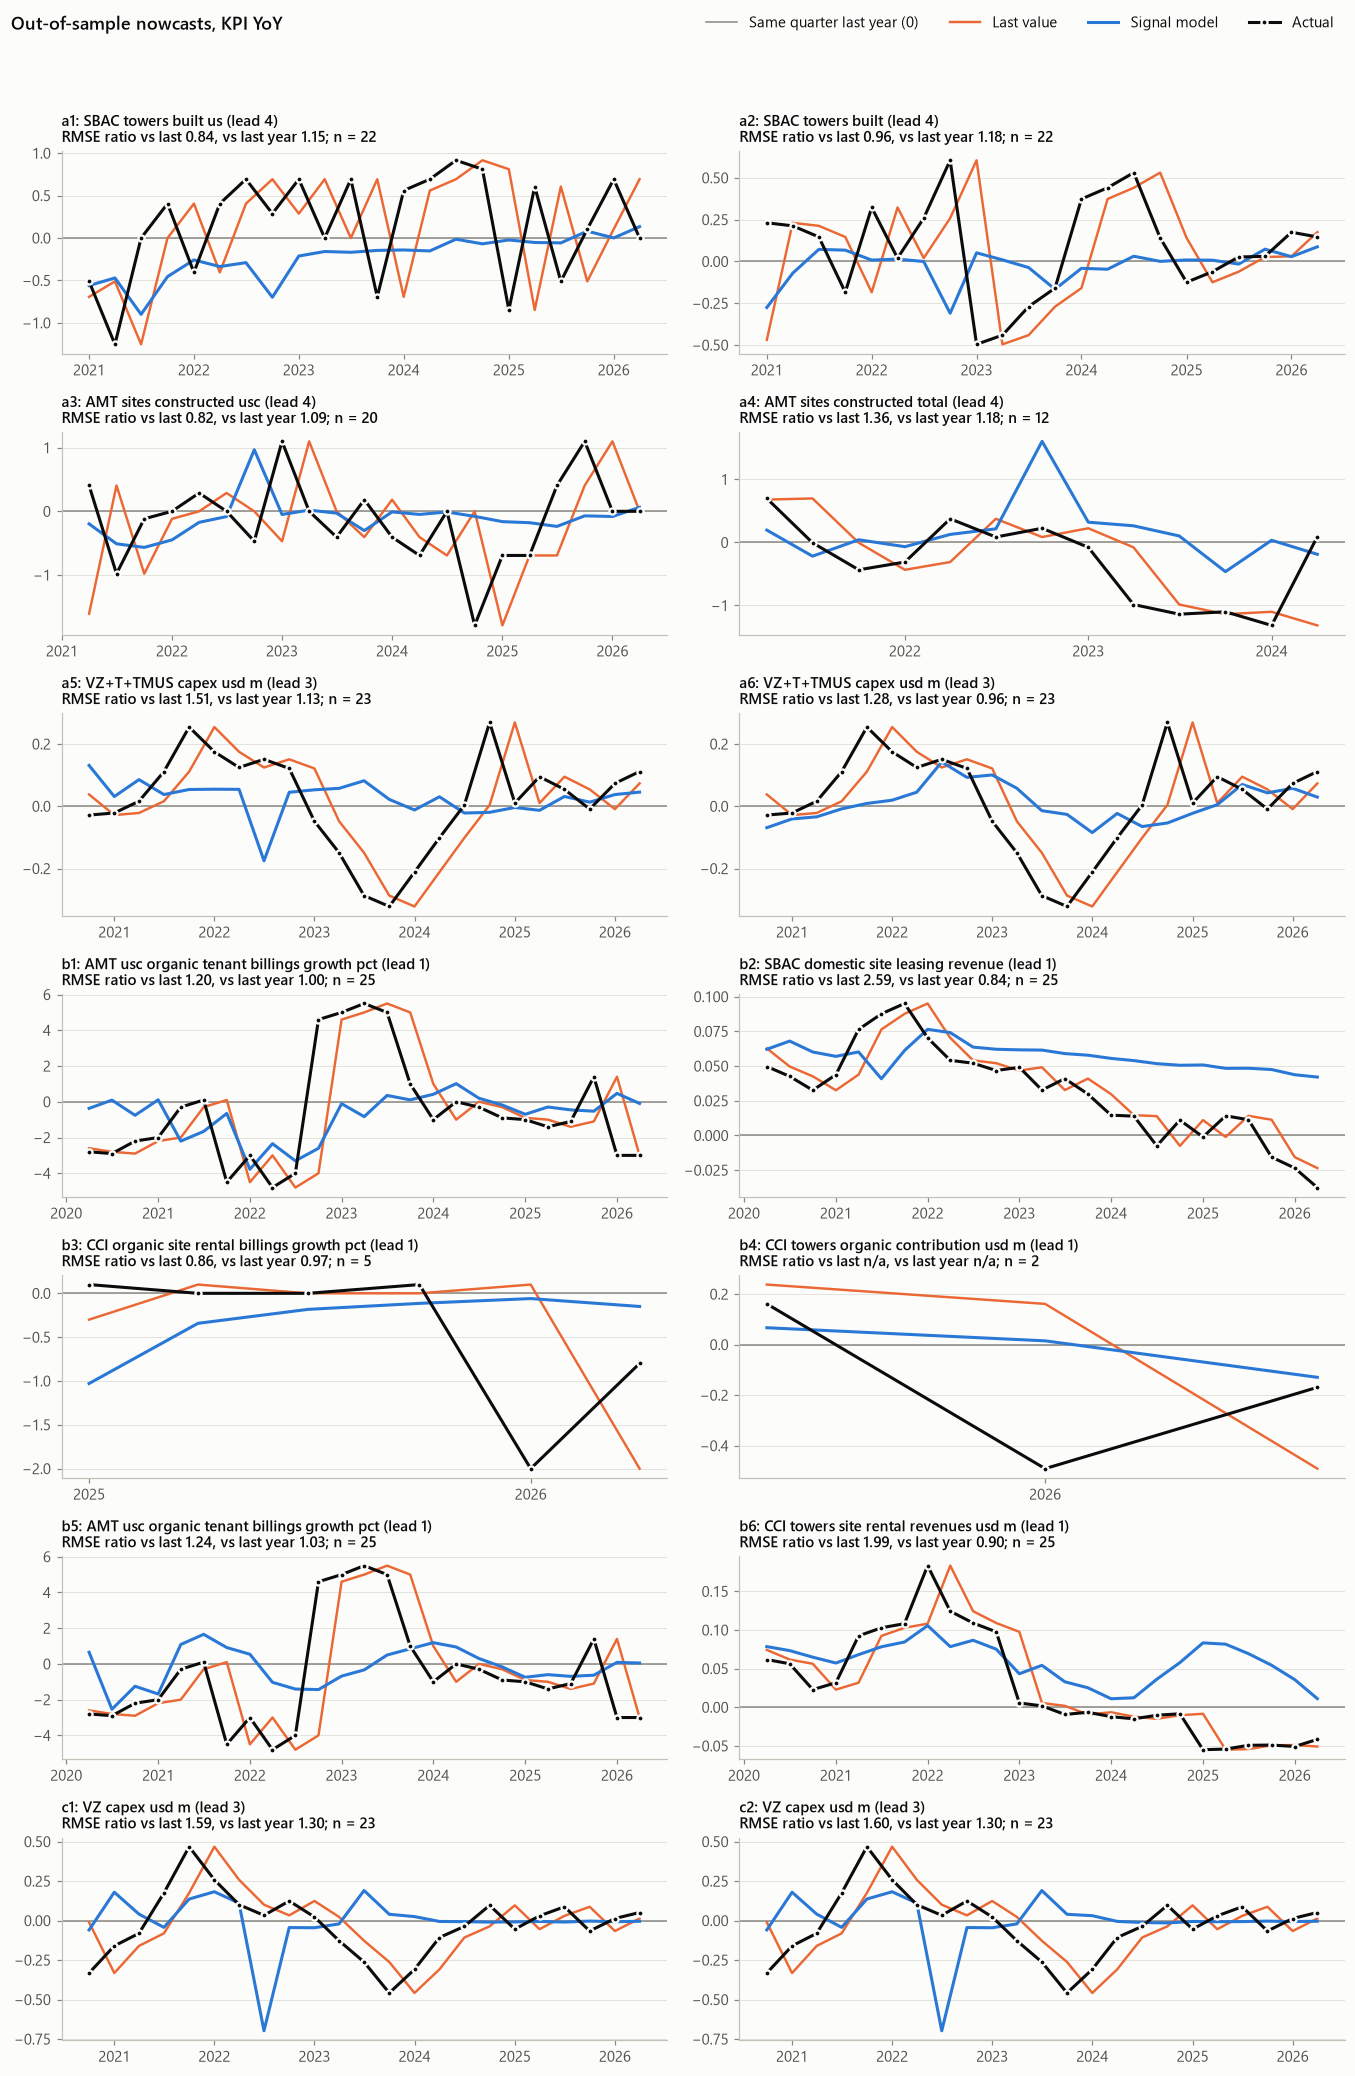

In [5]:
fc_keys = [k for k in keys if res.forecasts.filter(pl.col("key") == k).drop_nulls(["signal", "last"]).height > 1]
if not fc_keys:
    print(f"No pairing has two or more out-of-sample quarters yet ({backtest.MIN_TRAIN} earlier training pairs are "
          "needed before the first forecast); the nowcast needs a longer signal history.")
else:
    fig, axes = viz.small_multiples(len(fc_keys), ncols=2, panel=(6.2, 2.7))
    for ax, key in zip(axes, fc_keys):
        p = pairs[key]
        f = res.forecasts.filter(pl.col("key") == key).sort("period")
        ax.axhline(0, color=viz.MUTED, linewidth=1, label="Same quarter last year (0)")
        ax.plot(f["period"], f["last"], color=viz.SERIES[1], linewidth=1.6, label="Last value")
        ax.plot(f["period"], f["signal"], color=viz.SERIES[0], linewidth=2, label="Signal model")
        ax.plot(f["period"], f["actual"], color=viz.INK, linewidth=2, marker="o", markersize=4,
                markeredgecolor=viz.SURFACE, markeredgewidth=1.5, label="Actual")
        s = res.oos.filter(pl.col("key") == key).row(0, named=True)
        fmt = lambda v: "n/a" if v is None else f"{v:.2f}"
        ax.set_title(f"{key}: {p.kpi_entity} {p.kpi_metric.replace('_', ' ')} (lead {p.lead})\n"
                     f"RMSE ratio vs last {fmt(s['ratio_vs_last'])}, vs last year {fmt(s['ratio_vs_last_year'])}; "
                     f"n = {s['n_oos']}", fontsize=9.5)
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    handles, labels = axes[0].get_legend_handles_labels()
    top = 1 - 0.55 / fig.get_figheight()
    fig.legend(handles, labels, loc="upper right", ncols=4, bbox_to_anchor=(0.99, 1.0))
    fig.suptitle("Out-of-sample nowcasts, KPI YoY", x=0.01, y=1 - 0.12 / fig.get_figheight(), ha="left",
                 va="top", fontweight="semibold")
    fig.tight_layout(rect=(0, 0, 1, top))

In [6]:
res.oos.select("key", "signal", "kind", "kpi", "lead", "corr_at_lead", "best_lead_insample", "n_oos",
               "ratio_vs_last", "ratio_vs_last_year", "ratio_ar1x_vs_ar1")

key,signal,kind,kpi,lead,corr_at_lead,best_lead_insample,n_oos,ratio_vs_last,ratio_vs_last_year,ratio_ar1x_vs_ar1
str,str,str,str,i64,f64,i64,i64,f64,f64,f64
"""a1""","""private_and_carriers""","""new_or_unknown""","""SBAC towers_built_us""",4,0.136925,6,22,0.840284,1.151845,1.047415
"""a2""","""private_and_carriers""","""new_or_unknown""","""SBAC towers_built""",4,0.178216,6,22,0.957772,1.179013,1.089186
"""a3""","""private_and_carriers""","""new_or_unknown""","""AMT sites_constructed_usc""",4,0.154144,0,20,0.821936,1.085193,1.254117
"""a4""","""private_and_carriers""","""new_or_unknown""","""AMT sites_constructed_total""",4,0.401174,4,12,1.36347,1.175166,1.072408
"""a5""","""private_and_carriers""","""new_or_unknown""","""VZ+T+TMUS capex_usd_m""",3,0.199278,6,23,1.505205,1.130001,1.161556
"""a6""","""all""","""new_or_unknown""","""VZ+T+TMUS capex_usd_m""",3,0.424257,1,23,1.277481,0.959042,1.028309
"""b1""","""American Tower""","""modification""","""AMT usc_organic_tenant_billings_growth_pct""",1,-0.312313,4,25,1.200268,0.996155,1.024706
"""b2""","""SBA Communications""","""modification""","""SBAC domestic_site_leasing_revenue""",1,0.093277,0,25,2.588184,0.841612,1.055077
"""b3""","""Crown Castle""","""modification""","""CCI organic_site_rental_billings_growth_pct""",1,-0.034379,5,5,0.864181,0.970951,0.99111


## The 2026 shift: Crown Castle down, Vertical Bridge up
Crown Castle's tower filings fell through 2026 while Vertical Bridge's jumped in August–September. If Crown
Castle's work had moved to other filers (new filer codes, agents), filings on structures whose FCC ASR owner is
Crown Castle would keep arriving under other names. Left: monthly filings by company (hindsight entity). Right:
all filings on Crown Castle-owned structures, by who filed them.

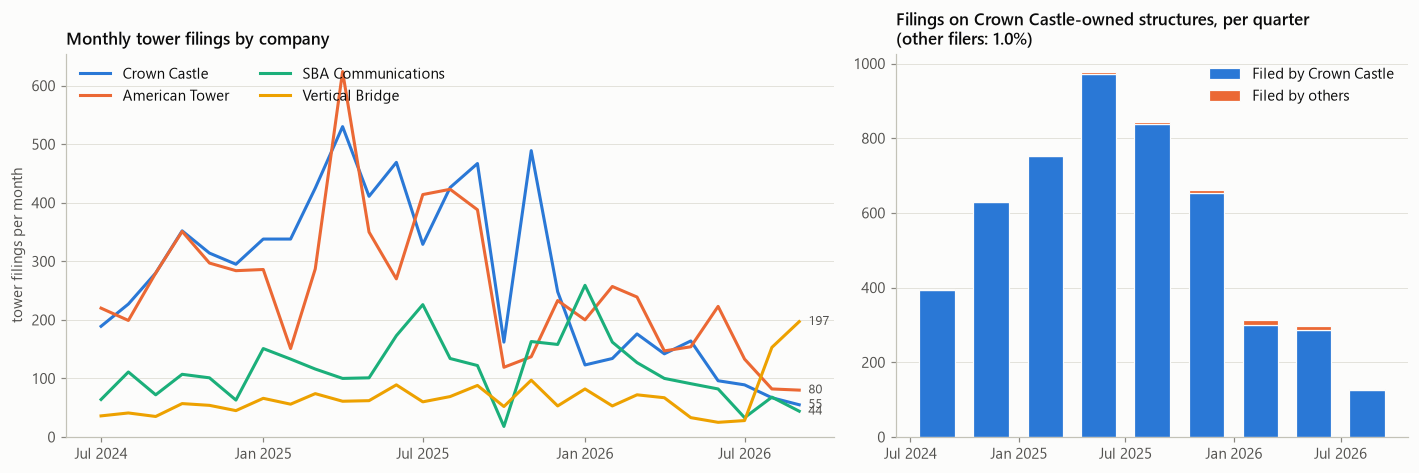

In [7]:
tw = report.load_tower()
since = date(2024, 7, 1)
last_full = tw["date_entered"].max().replace(day=1)
COMPANIES = [("Crown Castle", viz.SERIES[0]), ("American Tower", viz.SERIES[1]), ("SBA Communications", viz.SERIES[2]),
             ("Vertical Bridge", viz.SERIES[3])]
m = report.reit_monthly(tw, since).filter(pl.col("month") < last_full)

shift = (
    tw.filter((pl.col("asr_owner_entity") == "Crown Castle") & (pl.col("date_entered") >= since)
              & (pl.col("date_entered") < last_full))
    .with_columns(quarter=pl.col("date_entered").dt.truncate("1q"),
                  filer=pl.when(pl.col("entity") == "Crown Castle").then(pl.lit("Crown Castle")).otherwise(pl.lit("Other filers")))
    .group_by("quarter", "filer").len("n")
    .pivot(on="filer", index="quarter", values="n").fill_null(0).sort("quarter")
)
if "Other filers" not in shift.columns:
    shift = shift.with_columns(pl.lit(0).alias("Other filers"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1.5, 1]})
for name, color in COMPANIES:
    ax1.plot(m["month"], m[name], color=color, linewidth=2, label=name)
    ax1.annotate(f"{m[name][-1]}", (m["month"][-1], m[name][-1]), xytext=(6, 0), textcoords="offset points",
                 va="center", fontsize=8.5, color=viz.INK_2)
ax1.set_ylim(0, None)
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.set_ylabel("tower filings per month")
ax1.set_title("Monthly tower filings by company")
ax1.legend(loc="upper left", ncols=2)

x = [d + timedelta(days=45) for d in shift["quarter"]]
viz.stacked_columns(ax2, x, [shift["Crown Castle"].to_list(), shift["Other filers"].to_list()],
                    [viz.SERIES[0], viz.SERIES[1]], width=60, labels=["Filed by Crown Castle", "Filed by others"])
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
other_share = shift["Other filers"].sum() / max(shift["Crown Castle"].sum() + shift["Other filers"].sum(), 1)
ax2.set_title(f"Filings on Crown Castle-owned structures, per quarter\n(other filers: {other_share:.1%})")
ax2.legend(loc="upper right")
fig.tight_layout()

In [8]:
n_regs, n_later, by = report.same_structure_followups(tw)
print(f"Crown Castle filed on {n_regs:,} distinct ASR structures in 2024-25; {n_later:,} filings on those since 2026-01-01:")
display(by)
display(report.filer_shift(tw))
report.recent_owner_mix(tw)

Crown Castle filed on 5,525 distinct ASR structures in 2024-25; 134 filings on those since 2026-01-01:


entity,n
str,u32
"""Crown Castle""",130
"""SALT LAKE CITY DEPARTMENT OF AIRPORTS""",1
"""WALTON COUNTY GA""",1
"""T-Mobile""",1
"""Verizon""",1


entity,2024H2,2025H1,2025H2,2026H1,2026H2
str,u32,u32,u32,u32,u32
"""Crown Castle""",1023,1723,1491,588,126
"""AT&T""",7,2,13,16,2
"""Verizon""",0,3,0,2,0
"""SBA Communications""",0,1,1,0,0
"""T-Mobile""",0,0,0,1,0
"""SANTA BARBARA COUNTY""",0,1,0,0,0
"""SEDONA FIRE DISTRICT""",0,0,0,1,0
"""IRVINE RANCH WATER DISTRICT""",0,0,0,1,0
"""SALT LAKE CITY DEPARTMENT OF AIRPORTS""",0,0,0,1,0


asr_owner_entity,modification,new_build,unknown,total
str,u32,u32,u32,u32
"""Vertical Bridge""",302,2,0,304
"""<no ASR match>""",14,0,16,30
"""AT&T""",3,0,0,3
"""CONNECT HOLDING""",2,0,0,2
"""Verizon""",2,0,0,2
"""ALTA TOWERS""",2,0,0,2
"""NSIGHT TOWER HOLDINGS""",1,0,0,1
"""CUMULUS BROADCASTING""",1,0,0,1


## Point-in-time vs hindsight build kind (descriptive)
The backtest uses `pit_kind`. Stage 2's hindsight `build_kind` also knows about registrations and construction
after the filing; it is shown here only for comparison.

In [9]:
pk = pl.read_parquet(DataPaths.resolve().parquet / "pit_kinds.parquet")
display(features.kind_counts(pk))
features.pit_basis_shares(pk)

year,modification,new_or_unknown,hs_modification,hs_new_build,hs_unknown
i32,u32,u32,u32,u32,u32
2015,3162,5196,3155,2056,3147
2016,3069,3983,3018,1735,2299
2017,2947,3699,2917,2309,1420
2018,3778,4108,3771,2730,1385
2019,4237,4583,4251,2665,1904
2020,2768,3671,2773,2122,1544
2021,15190,6609,15720,1969,4110
2022,23371,6702,23817,1827,4429
2023,13860,4920,13840,2286,2654


year,prior_case,keyword,faa_built,none,asr_constructed,asr_registered
i32,f64,f64,f64,f64,f64,f64
2015,0.005,0.0,0.011,0.622,0.026,0.336
2016,0.012,0.001,0.012,0.565,0.03,0.381
2017,0.014,0.001,0.008,0.557,0.023,0.397
2018,0.009,0.001,0.005,0.521,0.038,0.425
2019,0.007,0.001,0.007,0.52,0.026,0.439
2020,0.011,0.001,0.01,0.57,0.048,0.36
2021,0.014,0.004,0.003,0.303,0.008,0.667
2022,0.033,0.01,0.001,0.223,0.01,0.723
2023,0.034,0.007,0.002,0.262,0.012,0.683
